# 实验 2：AFT 删失回归 (AFT Censored Regression)

In [41]:
import sys
import os
sys.path.append(os.path.abspath('.'))
%load_ext autoreload
%autoreload 2
import time
import numpy as np
import matplotlib.pyplot as plt
from models.aft import generate_aft_data
from algorithms.admm import run_u_admm
from utils.excel_utils import append_to_excel
from utils.eval_utils import calculate_metrics, evaluate_correlation

params = {
    'Experiment': 'AFT Survival',
    'm': 10, 
    'n': 200, # ⚠️ 注意：U-统计量是 O(n^2) 复杂度。n=200 的计算量是 n=100 的 4 倍！调参时建议用 100
    'p_prime': 5, 
    'p': 20, 
    'pc': 0.3,
    'T': 40, 
    'W_inner': 5, 
    'rho': 1.3, 
    'ic_type': 'bic', 
    'lambda_candidates': np.logspace(-2.5, -1.5, 10).tolist(),
    'noise_type': 't1',
    'rng_seed': 245,
    'run_baselines': False
}
np.random.seed(params['rng_seed'])

# 2. 生成数据
d_aft = generate_aft_data(
    m=params['m'], n=params['n'], p=params['p'], 
    pc=params['pc'], noise_type=params['noise_type'], rng_seed=params['rng_seed']
)
theta_true = d_aft['theta_true']

# 在此处由 SLSQP 求解器统一生成热启动参数
print('正在使用 SLSQP 求解器进行热启动初始化 (init_all_nodes)...')
from algorithms.admm import init_all_nodes
theta0_list, theta_naive = init_all_nodes(d_aft)
d_aft['theta0_list'] = theta0_list
d_aft['theta_naive'] = theta_naive

# 3. 运行 Proposed (U-ADMM)
t0 = time.time()
theta_u_a, theta_n_a, hist_a = run_u_admm(
    d_aft, T=params['T'], W_inner=params['W_inner'], 
    rho=params['rho'], verbose=True,
    lambda_candidates=params['lambda_candidates'],
    ic_type=params.get('ic_type', 'bic'),
    theta0_list=theta0_list
)
time_uadmm = time.time() - t0
theta_uadmm = theta_u_a[0]
print(f'Proposed 耗时: {time_uadmm:.1f}s')

# 4. 运行其他基线算法
theta_avg = theta_n_a
rmse_local, rmse_global, rmse_dgd = 0.0, 0.0, 0.0
time_global, time_dgd = 0.0, 0.0

if params['run_baselines']:
    # 2. Local MR (已在初始化阶段完成)
    local_rmses = [calculate_metrics(theta_true, th)['RMSE'] for th in theta0_list]
    rmse_local = np.mean(local_rmses)
    
    from algorithms.baselines import run_global_u_erm, run_dgd
    t0 = time.time()
    theta_global, hist_global = run_global_u_erm(d_aft, lambda_candidates=params['lambda_candidates'], ic_type=params.get('ic_type', 'bic'), init_theta=theta_naive, return_history=True)
    time_global = time.time() - t0
    rmse_global = calculate_metrics(theta_true, theta_global)['RMSE']
    print(f'Pooled MR 耗时: {time_global:.1f}s')
    
    t0 = time.time()
    theta_dgd, hist_dgd = run_dgd(d_aft, T=params['T'] * params['W_inner'], lr=0.1, lambda_candidates=params.get('lambda_candidates'), ic_type=params.get('ic_type', 'bic'), theta_init_list=theta0_list, return_history=True)
    time_dgd = time.time() - t0
    rmse_dgd = calculate_metrics(theta_true, theta_dgd)['RMSE']
    print(f'D-subGD 耗时: {time_dgd:.1f}s')



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  [t=0 init]  RMSE=0.829846
  [t= 1]  RMSE=0.346194, best_lam=0.0501, rho=1.0000, BIC=-0.0572
  [t= 2]  RMSE=0.194144, best_lam=0.0050, rho=1.0000, BIC=-0.1478
  [t= 3]  RMSE=0.167449, best_lam=0.0050, rho=1.0000, BIC=-0.1326
  [t= 4]  RMSE=0.108645, best_lam=0.0501, rho=1.0000, BIC=-0.1376
  [t= 5]  RMSE=0.096390, best_lam=0.0501, rho=1.0000, BIC=-0.1450
  [t= 6]  RMSE=0.094736, best_lam=0.0501, rho=1.0000, BIC=-0.1706
  [t= 7]  RMSE=0.097760, best_lam=0.0501, rho=1.0000, BIC=-0.1844
  [t= 8]  RMSE=0.100781, best_lam=0.0501, rho=1.0000, BIC=-0.1834
  [t= 9]  RMSE=0.102747, best_lam=0.0501, rho=1.0000, BIC=-0.1832
  [t=10]  RMSE=0.104194, best_lam=0.0501, rho=1.0000, BIC=-0.1829
  [t=11]  RMSE=0.105329, best_lam=0.0501, rho=1.0000, BIC=-0.1825
  [t=12]  RMSE=0.106091, best_lam=0.0501, rho=1.0000, BIC=-0.1824
  [t=13]  RMSE=0.106737, best_lam=0.0501, rho=1.0000, BIC=-0.1823
  [t=14]  RMSE=0.107201, b

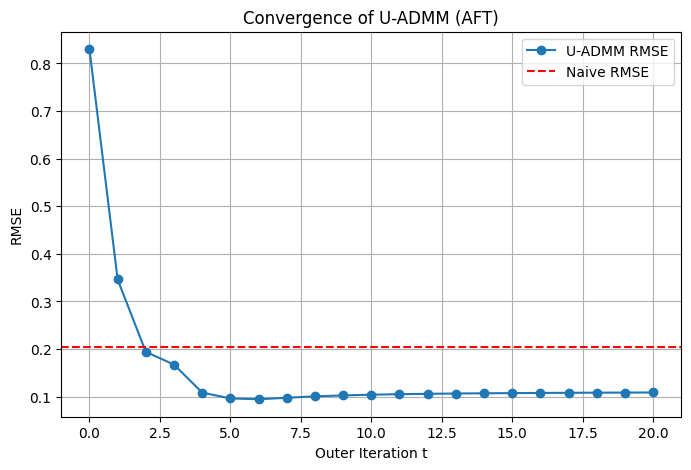

In [42]:
# 绘制收敛曲线
plt.figure(figsize=(8, 5))
plt.plot(hist_a['rmse'], marker='o', label='U-ADMM RMSE')
rmse_naive = np.linalg.norm(theta_n_a - d_aft['theta_true'])
plt.hlines(rmse_naive, xmin=0, xmax=total_steps, color='r', linestyle='--', label=f'Naive MR (RMSE={rmse_naive:.4f})')

if params['run_baselines']:
    plt.hlines(rmse_local, xmin=0, xmax=total_steps, color='g', linestyle='-.', label=f'Local MR (RMSE={rmse_local:.4f})')
    if 'hist_global' in locals() and hist_global is not None and 'rmse' in hist_global:
        plt.plot(hist_global['rmse'], color='m', linestyle=':', label=f'Pooled MR (RMSE={rmse_global:.4f})')
    else:
        plt.hlines(rmse_global, xmin=0, xmax=total_steps, color='m', linestyle=':', label=f'Pooled MR (RMSE={rmse_global:.4f})')
    if 'hist_dgd' in locals() and hist_dgd is not None and 'rmse' in hist_dgd:
        plt.plot(hist_dgd['rmse'], color='c', linestyle='-', label=f'D-subGD (RMSE={rmse_dgd:.4f})')
    else:
        plt.hlines(rmse_dgd, xmin=0, xmax=total_steps, color='c', linestyle='-', label=f'D-subGD (RMSE={rmse_dgd:.4f})')

plt.xlabel('Outer Iteration t')
plt.ylabel('RMSE')
plt.title('Convergence of U-ADMM (AFT)')
plt.legend()
plt.grid(True)
import os
os.makedirs('aft', exist_ok=True)
plt.savefig('aft/convergence_comparison.png')
plt.show()


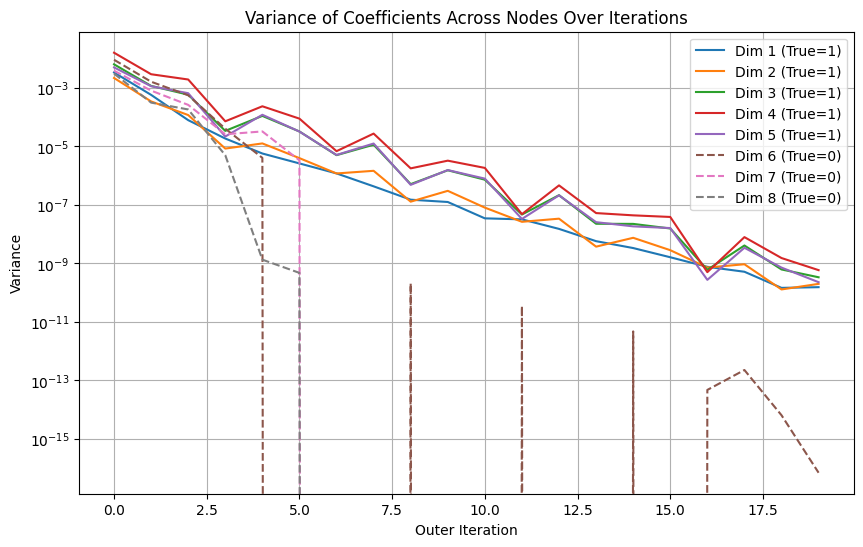

In [43]:
# 绘制系数方差变化图
debug_history = hist_a['debug']
T_iters = len(debug_history)
p = params['p']
variances = np.zeros((T_iters, p))

for t in range(T_iters):
    theta_t = debug_history[t]['theta_t']
    theta_mat = np.hstack(theta_t)
    variances[t, :] = np.var(theta_mat, axis=1)

plt.figure(figsize=(10, 6))
for i in range(params['p_prime']):
    plt.plot(range(T_iters), variances[:, i], label=f'Dim {i+1} (True=1)')
for i in range(params['p_prime'], min(params['p_prime']+3, p)):
    plt.plot(range(T_iters), variances[:, i], linestyle='--', label=f'Dim {i+1} (True=0)')

plt.title('Variance of Coefficients Across Nodes Over Iterations')
plt.xlabel('Outer Iteration')
plt.ylabel('Variance')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()


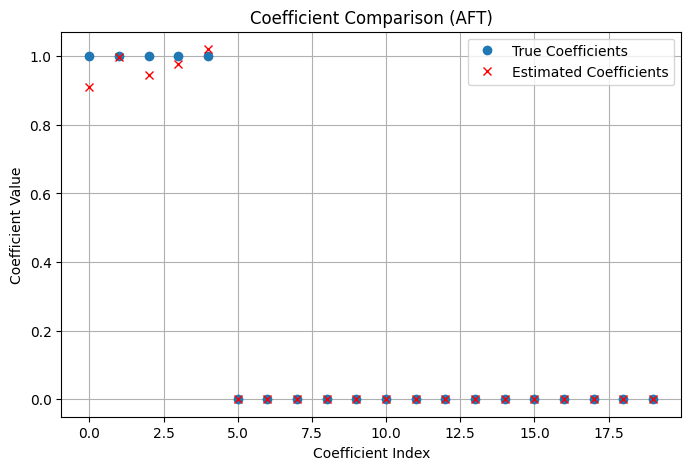

In [44]:
# 绘制系数比较图
plt.figure(figsize=(8, 5))
plt.plot(d_aft['theta_true'], marker='o', linestyle='None', label='True Coefficients')
plt.plot(theta_u_a[0], marker='x', color='r', linestyle='None', label='Estimated Coefficients')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Comparison (AFT)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# 计算指标并保存到 Excel
metrics_uadmm = calculate_metrics(theta_true, theta_uadmm)
metrics_avg = calculate_metrics(theta_true, theta_avg)
corr_metrics = evaluate_correlation(d_aft['X'], theta_true, theta_uadmm)

print(f"\n=== RMSE 结果 ({params['noise_type']} 噪声) ===")
if params['run_baselines']:
    print(f"1. Pooled MR (Global): {rmse_global:.4f}")
    print(f"2. Local MR:         {rmse_local:.4f}")
print(f"3. Avg MR (Naive):   {metrics_avg['RMSE']:.4f}")
if params['run_baselines']:
    print(f"4. D-subGD:          {rmse_dgd:.4f}")
print(f"5. Proposed (U-ADMM): {metrics_uadmm['RMSE']:.4f}")
print(f"\nPearson Correlation (Proposed): {corr_metrics['Pearson_Corr']:.4f}")
print(f"Kendall Correlation (Proposed): {corr_metrics['Kendall_Corr']:.4f}")
print(f"\n变量选择 F1-Score (Proposed): {metrics_uadmm['F1_Score']:.4f}")
print(f"变量选择 Recall (Proposed): {metrics_uadmm['Recall']:.4f}")
print(f"变量选择 Precision (Proposed): {metrics_uadmm['Precision']:.4f}")
print(f"变量选择 Accuracy (Proposed): {metrics_uadmm['Selection_Acc']:.4f}")

record = params.copy()
record['RMSE'] = metrics_uadmm['RMSE']
record['MAE'] = metrics_uadmm['MAE']
record['Selection_Acc'] = metrics_uadmm['Selection_Acc']
record['Precision'] = metrics_uadmm['Precision']
record['Recall'] = metrics_uadmm['Recall']
record['F1_Score'] = metrics_uadmm['F1_Score']
record['Pearson_Corr'] = corr_metrics['Pearson_Corr']
record['Kendall_Corr'] = corr_metrics['Kendall_Corr']
record['Pairwise_Correlation'] = (corr_metrics['Kendall_Corr'] + 1) / 2
record['Avg_RMSE'] = metrics_avg['RMSE']
if params['run_baselines']:
    record['Pooled_RMSE'] = rmse_global
    record['Local_RMSE'] = rmse_local
    record['DGD_RMSE'] = rmse_dgd

# 记录第一个节点的所有系数估计
for i, coef in enumerate(theta_uadmm.flatten()):
    record[f'theta_{i}'] = coef

os.makedirs('aft', exist_ok=True)
append_to_excel('aft/experiment_results.xlsx', record)
print('结果已保存到 aft/experiment_results.xlsx')



=== RMSE 结果 (normal 噪声) ===
3. Avg MR (Naive):   0.2044
5. Proposed (U-ADMM): 0.1089

Pairwise Correlation (Proposed): 0.9927
Pearson Correlation (Proposed): 0.9997
Kendall Correlation (Proposed): 0.9854

变量选择 F1-Score (Proposed): 1.0000
变量选择 Recall (Proposed): 1.0000
变量选择 Precision (Proposed): 1.0000
变量选择 Accuracy (Proposed): 1.0000
结果已保存到 exp2/experiment_results.xlsx
